# Load and Imports

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, classification_report
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights


# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Config
IMG_SIZE = (128, 128)
EN_SIZE     = 224   # EfficientNet native size
BATCH_SIZE = 32
EPOCHS_CNN = 20
EPOCHS_FINETUNE = 10

print('PyTorch version:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version: 2.5.1+cu121
Device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
VRAM: 12.9 GB


**Instructions:** Download the dataset from Kaggle and unzip it.  


In [2]:
DATA_DIR = Path('DATASET')

TRAIN_DIR = DATA_DIR / 'TRAIN'
TEST_DIR  = DATA_DIR / 'TEST'

CLASS_NAMES = ['O', 'R']   # Organic, Recyclable
LABEL_MAP   = {'O': 0, 'R': 1}  # 0 = Organic, 1 = Recyclable

def count_images(split_dir):
    counts = {}
    for cls in CLASS_NAMES:
        p = split_dir / cls
        counts[cls] = len(list(p.glob('*.jpg')) + list(p.glob('*.jpeg')) + list(p.glob('*.png')))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('Dataset Statistics')
print(f"Train: O: {train_counts['O']:,}   R: {train_counts['R']:,}   Total: {sum(train_counts.values()):,}")
print(f"Test: O: {test_counts['O']:,}    R: {test_counts['R']:,}    Total: {sum(test_counts.values()):,}")
print(f"Grand total: {sum(train_counts.values()) + sum(test_counts.values()):,}")

Dataset Statistics
Train: O: 12,565   R: 9,999   Total: 22,564
Test: O: 1,401    R: 1,112    Total: 2,513
Grand total: 25,077


### Exploratory Data Analysis (EDA)

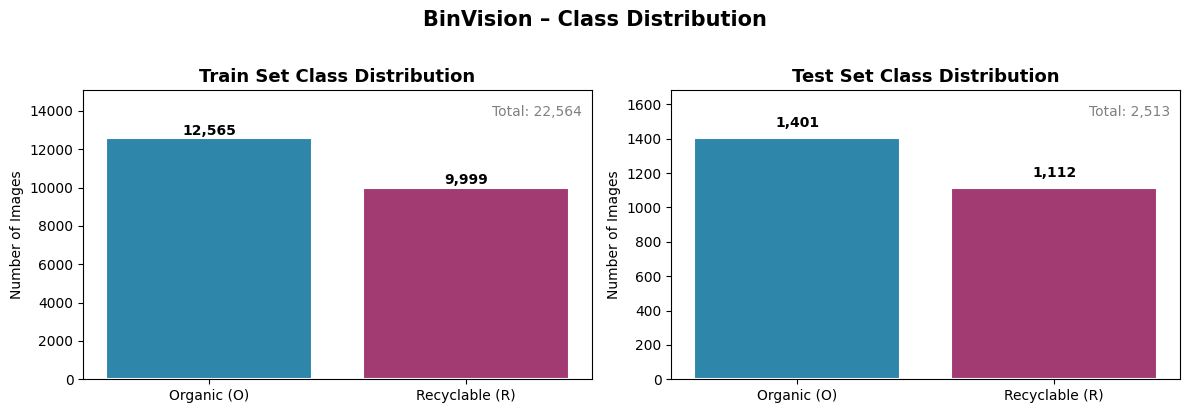

In [3]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    bars = ax.bar(['Organic (O)', 'Recyclable (R)'],
                  [counts['O'], counts['R']],
                  color=['#2E86AB', '#A23B72'], edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split} Set Class Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')
    total = sum(counts.values())
    ax.set_ylim(0, max(counts.values()) * 1.2)
    ax.text(0.98, 0.95, f'Total: {total:,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='grey')

plt.suptitle('BinVision – Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

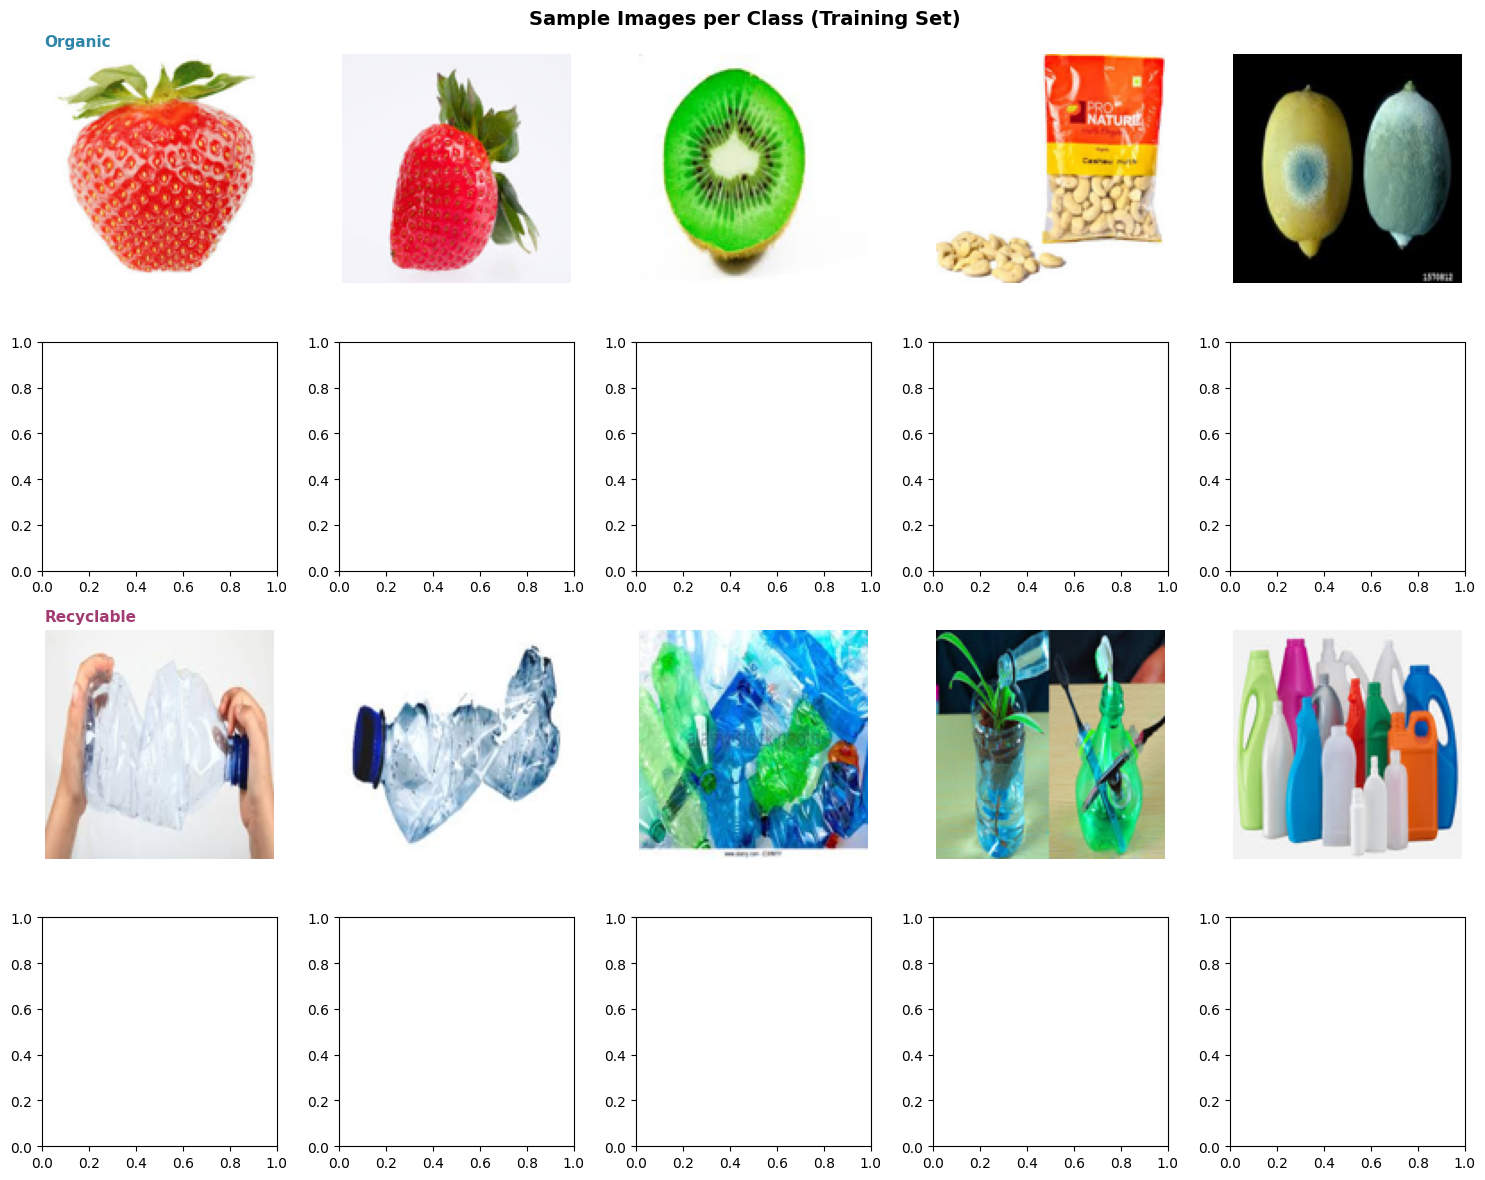

In [4]:
# Sample Image Grid
def load_sample_images(class_dir, n=10):
    files = list(class_dir.glob('*.jpg'))[:n] + list(class_dir.glob('*.jpeg'))[:n]
    files = files[:n]
    images = [np.array(Image.open(f).convert('RGB').resize(IMG_SIZE)) for f in files]
    return images

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
class_labels = ['Organic', 'Recyclable']
class_dirs   = [TRAIN_DIR / 'O', TRAIN_DIR / 'R']
colors       = ['#2E86AB', '#A23B72']

for row_block, (cls_name, cls_dir, color) in enumerate(zip(class_labels, class_dirs, colors)):
    samples = load_sample_images(cls_dir, n=10)
    for col, img in enumerate(samples[:5]):
        ax = axes[row_block * 2 + (0 if col < 5 else 1)][col % 5]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(cls_name, fontsize=11, fontweight='bold', color=color, loc='left')

plt.suptitle('Sample Images per Class (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

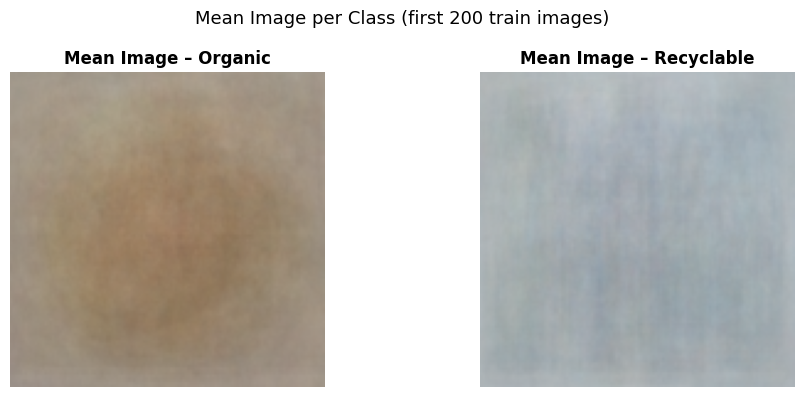

In [5]:
# Mean Image per Class
def compute_mean_image(class_dir, n=200):
    files = (list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg')))[:n]
    imgs  = np.array([np.array(Image.open(f).convert('RGB').resize(IMG_SIZE)) / 255.0 for f in files])
    return imgs.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cls_name, cls_dir) in zip(axes, zip(class_labels, class_dirs)):
    mean_img = compute_mean_image(cls_dir)
    ax.imshow(mean_img)
    ax.set_title(f'Mean Image – {cls_name}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('Mean Image per Class (first 200 train images)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_mean_image.png', dpi=150, bbox_inches='tight')
plt.show()

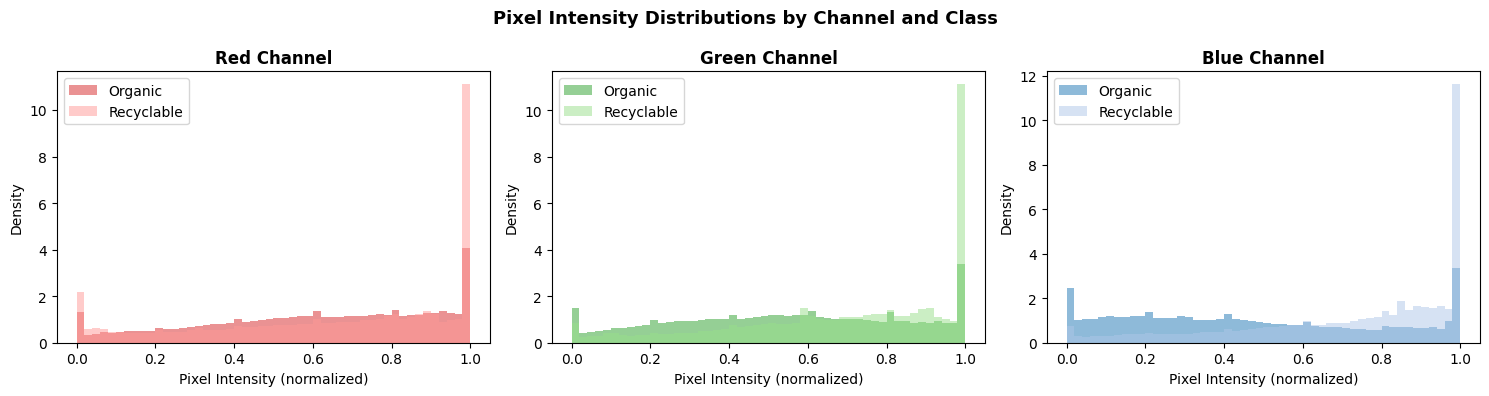

In [6]:
# Pixel Intensity Histograms 
def get_pixel_values(class_dir, n=100):
    files = (list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg')))[:n]
    pixels = []
    for f in files:
        img = np.array(Image.open(f).convert('RGB').resize(IMG_SIZE)) / 255.0
        pixels.append(img.reshape(-1, 3))
    return np.vstack(pixels)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names  = ['Red', 'Green', 'Blue']
channel_colors = [['#d62728', '#ff9896'], ['#2ca02c', '#98df8a'], ['#1f77b4', '#aec7e8']]

for cls_name, cls_dir, style in zip(class_labels, class_dirs, ['-', '--']):
    pix = get_pixel_values(cls_dir)
    for ch, (ax, ch_name, ch_cols) in enumerate(zip(axes, channel_names, channel_colors)):
        color_idx = 0 if cls_name == 'Organic' else 1
        ax.hist(pix[:, ch], bins=50, alpha=0.5, label=cls_name,
                color=ch_cols[color_idx], density=True)
        ax.set_title(f'{ch_name} Channel', fontweight='bold')
        ax.set_xlabel('Pixel Intensity (normalized)')
        ax.set_ylabel('Density')
        ax.legend()

plt.suptitle('Pixel Intensity Distributions by Channel and Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_pixel_hist.png', dpi=150, bbox_inches='tight')
plt.show()

### Data Preprocessing

In [7]:
# PyTorch Transforms

train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                          # [0,255] → [0,1], HWC → CHW
    transforms.Normalize([0.485, 0.456, 0.406],     # ImageNet mean/std
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load full train set, split 85/15 into train/val
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
# Val set should use val transforms (no augmentation)
val_ds.dataset = copy.deepcopy(full_train)
val_ds.dataset.transform = val_test_transforms

test_ds = datasets.ImageFolder(TEST_DIR, transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Class mapping:', full_train.class_to_idx)   # {'O': 0, 'R': 1}
print(f'Train: {train_size:,} | Val: {val_size:,} | Test: {len(test_ds):,}')

Class mapping: {'O': 0, 'R': 1}
Train: 19,180 | Val: 3,384 | Test: 2,513


In [8]:
# Flat Feature Matrix for Sklearn Baselines
# NOTE: loading all images into memory may take a few minutes

def load_flat_dataset(split_dir, img_size=IMG_SIZE, max_per_class=None):
    X, y = [], []
    for cls, label in LABEL_MAP.items():
        files = list((split_dir / cls).glob('*.jpg')) + list((split_dir / cls).glob('*.jpeg'))
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            try:
                img = Image.open(f).convert('RGB').resize(img_size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(label)
            except Exception:
                pass
    return np.array(X), np.array(y)

# NOTE: adjust max_per_class to adjust use of dataset (can use less for speed/testing purposes)
print('Loading flat train features...')
X_train_flat, y_train_flat = load_flat_dataset(TRAIN_DIR)
print('Loading flat test features...')
X_test_flat,  y_test_flat  = load_flat_dataset(TEST_DIR)

print(f'X_train_flat shape: {X_train_flat.shape}')
print(f'X_test_flat shape:  {X_test_flat.shape}')

Loading flat train features...
Loading flat test features...
X_train_flat shape: (22564, 49152)
X_test_flat shape:  (2513, 49152)


In [9]:
import os, joblib
os.makedirs('saved', exist_ok=True)
np.savez_compressed('saved/flat_features.npz',
    X_train=X_train_flat, y_train=y_train_flat,
    X_test=X_test_flat,   y_test=y_test_flat)
print('Saved: saved/flat_features.npz')

Saved: saved/flat_features.npz


### Model 1: Logistic Regression (Baseline)

In [10]:
lr_model = LogisticRegression(max_iter=500, C=1.0, solver='saga', n_jobs=-1, random_state=SEED)
lr_model.fit(X_train_flat, y_train_flat)

y_pred_lr  = lr_model.predict(X_test_flat)
y_prob_lr  = lr_model.predict_proba(X_test_flat)[:, 1]

lr_acc     = accuracy_score(y_test_flat, y_pred_lr)
lr_f1      = f1_score(y_test_flat, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test_flat, y_prob_lr)

print('=== Logistic Regression Results ===')
print(f'Accuracy:  {lr_acc:.4f}')
print(f'F1-Score:  {lr_f1:.4f}')
print(f'ROC-AUC:   {lr_roc_auc:.4f}')
print()
print(classification_report(y_test_flat, y_pred_lr, target_names=['Organic', 'Recyclable']))

c:\Users\notdu\anaconda3\envs\cs4100\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression Results ===
Accuracy:  0.8233
F1-Score:  0.7863
ROC-AUC:   0.8784

              precision    recall  f1-score   support

     Organic       0.81      0.89      0.85      1401
  Recyclable       0.85      0.73      0.79      1112

    accuracy                           0.82      2513
   macro avg       0.83      0.81      0.82      2513
weighted avg       0.83      0.82      0.82      2513



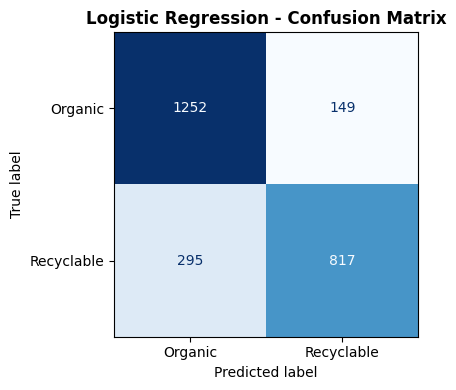

In [11]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_flat, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=['Organic', 'Recyclable'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
joblib.dump(lr_model, 'saved/lr_model.joblib')
print('Saved: saved/lr_model.joblib')

Saved: saved/lr_model.joblib


### Model 2: Random Forest (Baseline)

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, n_jobs=-1,
    random_state=SEED, class_weight='balanced'
)
rf_model.fit(X_train_flat, y_train_flat)

y_pred_rf  = rf_model.predict(X_test_flat)
y_prob_rf  = rf_model.predict_proba(X_test_flat)[:, 1]

rf_acc     = accuracy_score(y_test_flat, y_pred_rf)
rf_f1      = f1_score(y_test_flat, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test_flat, y_prob_rf)

print('=== Random Forest Results ===')
print(f'Accuracy:  {rf_acc:.4f}')
print(f'F1-Score:  {rf_f1:.4f}')
print(f'ROC-AUC:   {rf_roc_auc:.4f}')
print()
print(classification_report(y_test_flat, y_pred_rf, target_names=['Organic', 'Recyclable']))

=== Random Forest Results ===
Accuracy:  0.8699
F1-Score:  0.8343
ROC-AUC:   0.9473

              precision    recall  f1-score   support

     Organic       0.83      0.97      0.89      1401
  Recyclable       0.96      0.74      0.83      1112

    accuracy                           0.87      2513
   macro avg       0.89      0.86      0.86      2513
weighted avg       0.88      0.87      0.87      2513



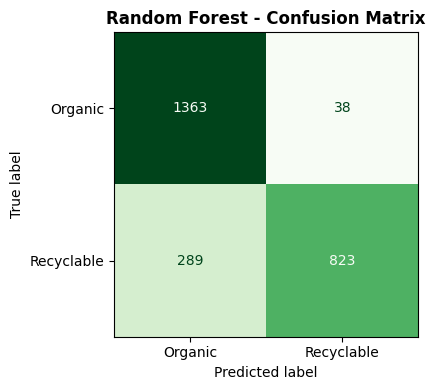

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_flat, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Organic', 'Recyclable'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
joblib.dump(rf_model, 'saved/rf_model.joblib')
print('Saved: saved/rf_model.joblib')

Saved: saved/rf_model.joblib


### Model 3: SVM (PCA + LinearSVC)

In [16]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=300, random_state=SEED)),
    ('clf',    CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=SEED))),
])

print('Training SVM...')
svm_pipe.fit(X_train_flat, y_train_flat)

y_pred_svm  = svm_pipe.predict(X_test_flat)
y_prob_svm  = svm_pipe.predict_proba(X_test_flat)[:, 1]

svm_acc     = accuracy_score(y_test_flat, y_pred_svm)
svm_f1      = f1_score(y_test_flat, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test_flat, y_prob_svm)

print('=== SVM (PCA + LinearSVC) ===')
print(f'Accuracy:  {svm_acc:.4f}')
print(f'F1-Score:  {svm_f1:.4f}')
print(f'ROC-AUC:   {svm_roc_auc:.4f}')
print()
print(classification_report(y_test_flat, y_pred_svm, target_names=['Organic', 'Recyclable']))

Training SVM...
=== SVM (PCA + LinearSVC) ===
Accuracy:  0.8635
F1-Score:  0.8319
ROC-AUC:   0.9122

              precision    recall  f1-score   support

     Organic       0.83      0.94      0.89      1401
  Recyclable       0.91      0.76      0.83      1112

    accuracy                           0.86      2513
   macro avg       0.87      0.85      0.86      2513
weighted avg       0.87      0.86      0.86      2513



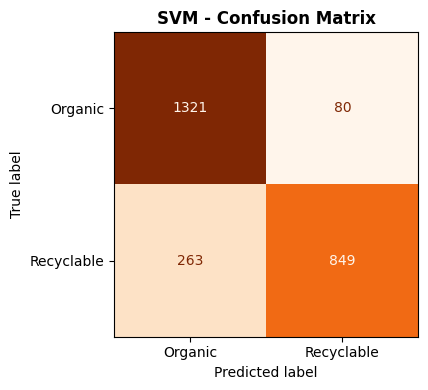

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_flat, y_pred_svm)
ConfusionMatrixDisplay(cm, display_labels=['Organic', 'Recyclable']).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('SVM - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
joblib.dump(svm_pipe, 'saved/svm_pipe.joblib')
print('Saved: saved/svm_pipe.joblib')

Saved: saved/svm_pipe.joblib


### Model 4: Custom CNN

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, 3, padding=1),  nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.head(self.features(x))


counts  = np.array([train_counts['O'], train_counts['R']], dtype=np.float32)
weights = torch.tensor(1.0 / counts)
weights = (weights / weights.sum()).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)

cnn_model     = SimpleCNN().to(DEVICE)
optimizer_cnn = optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=EPOCHS_CNN)
print(f'Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

Parameters: 616,738


In [20]:
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (out.argmax(1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


def predict(model, loader, device):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for X, y in loader:
            out = model(X.to(device))
            p   = torch.softmax(out, 1)
            preds.extend(out.argmax(1).cpu().numpy())
            probs.extend(p[:, 1].cpu().numpy())
            labels.extend(y.numpy())
    return np.array(preds), np.array(probs), np.array(labels)

In [21]:
cnn_hist = {'tl': [], 'vl': [], 'ta': [], 'va': []}
best_acc, best_state = 0.0, None

print(f'Training CNN ({EPOCHS_CNN} epochs)...')
for ep in range(EPOCHS_CNN):
    t0 = time.time()
    tl, ta = run_epoch(cnn_model, train_loader, optimizer_cnn, criterion, DEVICE, train=True)
    vl, va = run_epoch(cnn_model, val_loader,   optimizer_cnn, criterion, DEVICE, train=False)
    scheduler_cnn.step()
    cnn_hist['tl'].append(tl); cnn_hist['vl'].append(vl)
    cnn_hist['ta'].append(ta); cnn_hist['va'].append(va)
    if va > best_acc:
        best_acc   = va
        best_state = copy.deepcopy(cnn_model.state_dict())
    print(f'[{ep+1:02d}/{EPOCHS_CNN}] loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}  {time.time()-t0:.1f}s')

cnn_model.load_state_dict(best_state)
print(f'Best val acc: {best_acc:.4f}')

Training CNN (20 epochs)...
[01/20] loss 0.4556/0.4164  acc 0.8022/0.8262  65.2s
[02/20] loss 0.4209/0.3857  acc 0.8193/0.8366  22.9s
[03/20] loss 0.4004/0.3574  acc 0.8346/0.8534  22.7s
[04/20] loss 0.3909/0.3488  acc 0.8391/0.8490  22.8s
[05/20] loss 0.3730/0.3619  acc 0.8475/0.8528  22.7s
[06/20] loss 0.3611/0.3068  acc 0.8557/0.8821  22.7s
[07/20] loss 0.3518/0.3115  acc 0.8569/0.8788  22.6s
[08/20] loss 0.3390/0.3090  acc 0.8644/0.8735  22.7s
[09/20] loss 0.3326/0.2915  acc 0.8690/0.8836  22.7s
[10/20] loss 0.3248/0.2913  acc 0.8719/0.8877  22.8s
[11/20] loss 0.3204/0.2807  acc 0.8728/0.8895  22.9s
[12/20] loss 0.3168/0.2841  acc 0.8761/0.8862  22.8s
[13/20] loss 0.3053/0.2681  acc 0.8811/0.8907  22.8s
[14/20] loss 0.3012/0.2744  acc 0.8833/0.8877  22.9s
[15/20] loss 0.2942/0.2646  acc 0.8869/0.8936  23.0s
[16/20] loss 0.2896/0.2638  acc 0.8884/0.8927  23.1s
[17/20] loss 0.2833/0.2613  acc 0.8885/0.8939  22.8s
[18/20] loss 0.2856/0.2646  acc 0.8893/0.8904  22.7s
[19/20] loss 0.282

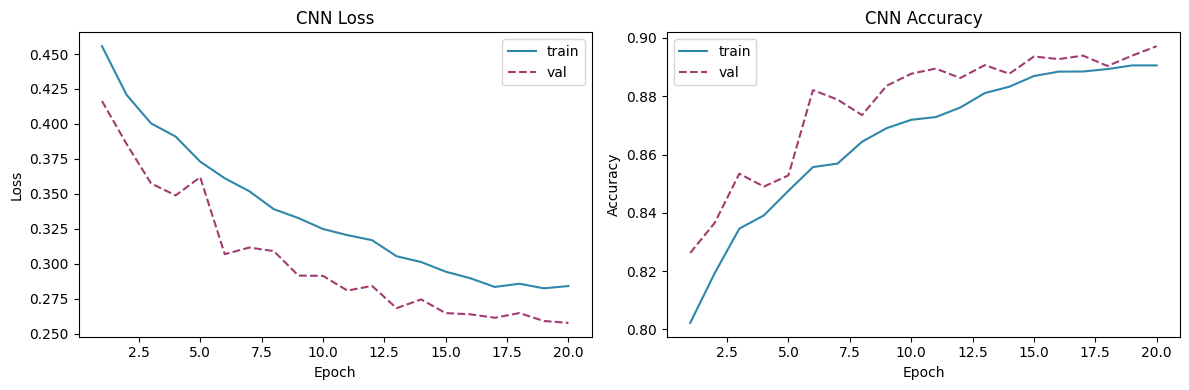

=== SimpleCNN ===
Accuracy:  0.9085
F1-Score:  0.8911
ROC-AUC:   0.9685

              precision    recall  f1-score   support

     Organic       0.89      0.96      0.92      1401
  Recyclable       0.94      0.85      0.89      1112

    accuracy                           0.91      2513
   macro avg       0.91      0.90      0.91      2513
weighted avg       0.91      0.91      0.91      2513



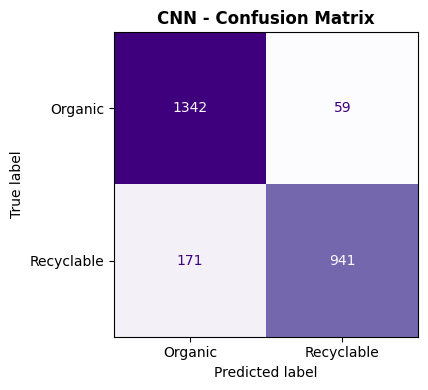

In [22]:
ep = range(1, EPOCHS_CNN + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep, cnn_hist['tl'], label='train', color='#2E86AB')
axes[0].plot(ep, cnn_hist['vl'], label='val',   color='#A23B72', linestyle='--')
axes[0].set(xlabel='Epoch', ylabel='Loss',     title='CNN Loss'); axes[0].legend()
axes[1].plot(ep, cnn_hist['ta'], label='train', color='#2E86AB')
axes[1].plot(ep, cnn_hist['va'], label='val',   color='#A23B72', linestyle='--')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='CNN Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_cnn, y_prob_cnn, y_true_cnn = predict(cnn_model, test_loader, DEVICE)
cnn_acc     = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_f1      = f1_score(y_true_cnn, y_pred_cnn)
cnn_roc_auc = roc_auc_score(y_true_cnn, y_prob_cnn)

print('=== SimpleCNN ===')
print(f'Accuracy:  {cnn_acc:.4f}')
print(f'F1-Score:  {cnn_f1:.4f}')
print(f'ROC-AUC:   {cnn_roc_auc:.4f}')
print()
print(classification_report(y_true_cnn, y_pred_cnn, target_names=['Organic', 'Recyclable']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true_cnn, y_pred_cnn),
                       display_labels=['Organic', 'Recyclable']).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('CNN - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
torch.save({
    'state_dict': cnn_model.state_dict(),
    'img_size':   IMG_SIZE,
    'class_map':  {'O': 0, 'R': 1},
}, 'saved/cnn_best.pt')
print('Saved: saved/cnn_best.pt')

Saved: saved/cnn_best.pt


### Model 5: EfficientNet-B0 (Transfer Learning)

In [24]:
en_train_tf = transforms.Compose([
    transforms.Resize((EN_SIZE, EN_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
en_test_tf = transforms.Compose([
    transforms.Resize((EN_SIZE, EN_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_en = datasets.ImageFolder(TRAIN_DIR, transform=en_train_tf)
val_n   = int(0.15 * len(full_en))
tr_ds, va_ds = random_split(full_en, [len(full_en) - val_n, val_n],
                             generator=torch.Generator().manual_seed(SEED))
va_ds.dataset           = copy.deepcopy(full_en)
va_ds.dataset.transform = en_test_tf
test_en = datasets.ImageFolder(TEST_DIR, transform=en_test_tf)

train_loader_en = DataLoader(tr_ds,   batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_en   = DataLoader(va_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_en  = DataLoader(test_en, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

en_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
en_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(en_model.classifier[1].in_features, 2),
)
en_model = en_model.to(DEVICE)
print(f'EfficientNet-B0 total params: {sum(p.numel() for p in en_model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\notdu/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 41.2MB/s]

EfficientNet-B0 total params: 4,010,110


In [25]:
en_hist = {'tl': [], 'vl': [], 'ta': [], 'va': []}
best_en_acc, best_en_state = 0.0, None

for p in en_model.features.parameters():
    p.requires_grad = False

opt1 = optim.AdamW(en_model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=EPOCHS_FINETUNE)

print(f'Phase 1 - head only ({EPOCHS_FINETUNE} epochs)')
for ep in range(EPOCHS_FINETUNE):
    t0 = time.time()
    tl, ta = run_epoch(en_model, train_loader_en, opt1, criterion, DEVICE, train=True)
    vl, va = run_epoch(en_model, val_loader_en,   opt1, criterion, DEVICE, train=False)
    sch1.step()
    en_hist['tl'].append(tl); en_hist['vl'].append(vl)
    en_hist['ta'].append(ta); en_hist['va'].append(va)
    if va > best_en_acc:
        best_en_acc   = va
        best_en_state = copy.deepcopy(en_model.state_dict())
    print(f'[{ep+1:02d}/{EPOCHS_FINETUNE}] loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}  {time.time()-t0:.1f}s')

for p in en_model.parameters():
    p.requires_grad = False
for block in list(en_model.features[-3:]):
    for p in block.parameters():
        p.requires_grad = True
for p in en_model.classifier.parameters():
    p.requires_grad = True

opt2 = optim.AdamW(filter(lambda p: p.requires_grad, en_model.parameters()), lr=1e-4, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_FINETUNE)

print()
print(f'Phase 2 - partial unfreeze ({EPOCHS_FINETUNE} epochs)')
for ep in range(EPOCHS_FINETUNE):
    t0 = time.time()
    tl, ta = run_epoch(en_model, train_loader_en, opt2, criterion, DEVICE, train=True)
    vl, va = run_epoch(en_model, val_loader_en,   opt2, criterion, DEVICE, train=False)
    sch2.step()
    en_hist['tl'].append(tl); en_hist['vl'].append(vl)
    en_hist['ta'].append(ta); en_hist['va'].append(va)
    if va > best_en_acc:
        best_en_acc   = va
        best_en_state = copy.deepcopy(en_model.state_dict())
    print(f'[{ep+1:02d}/{EPOCHS_FINETUNE}] loss {tl:.4f}/{vl:.4f}  acc {ta:.4f}/{va:.4f}  {time.time()-t0:.1f}s')

en_model.load_state_dict(best_en_state)
print()
print(f'Best val acc: {best_en_acc:.4f}')

Phase 1 - head only (10 epochs)
[01/10] loss 0.2951/0.2162  acc 0.8859/0.9176  30.0s
[02/10] loss 0.2470/0.1987  acc 0.9047/0.9235  29.6s
[03/10] loss 0.2472/0.1978  acc 0.9022/0.9208  29.9s
[04/10] loss 0.2341/0.2004  acc 0.9074/0.9187  30.0s
[05/10] loss 0.2425/0.1898  acc 0.9050/0.9252  29.9s
[06/10] loss 0.2432/0.1964  acc 0.9046/0.9220  30.0s
[07/10] loss 0.2334/0.1895  acc 0.9090/0.9229  30.0s
[08/10] loss 0.2326/0.1915  acc 0.9095/0.9235  30.4s
[09/10] loss 0.2314/0.1939  acc 0.9099/0.9252  30.4s
[10/10] loss 0.2320/0.1903  acc 0.9090/0.9241  30.3s

Phase 2 - partial unfreeze (10 epochs)
[01/10] loss 0.1886/0.1221  acc 0.9284/0.9536  30.3s
[02/10] loss 0.1311/0.1042  acc 0.9481/0.9592  30.2s
[03/10] loss 0.1042/0.1082  acc 0.9607/0.9572  29.9s
[04/10] loss 0.0808/0.0993  acc 0.9704/0.9598  30.0s
[05/10] loss 0.0641/0.0974  acc 0.9746/0.9660  30.5s
[06/10] loss 0.0576/0.1046  acc 0.9782/0.9595  30.6s
[07/10] loss 0.0459/0.0963  acc 0.9826/0.9634  30.6s
[08/10] loss 0.0417/0.0974 

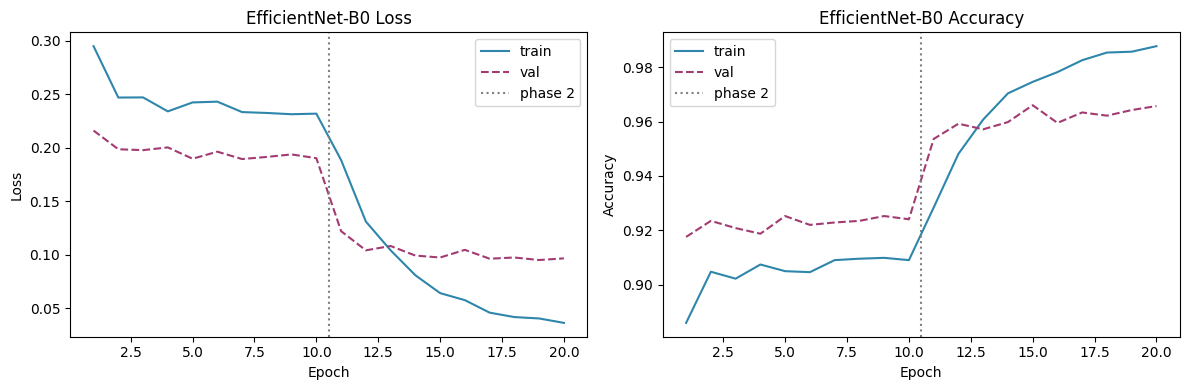

=== EfficientNet-B0 ===
Accuracy:  0.8993
F1-Score:  0.8741
ROC-AUC:   0.9827

              precision    recall  f1-score   support

     Organic       0.86      0.99      0.92      1401
  Recyclable       0.98      0.79      0.87      1112

    accuracy                           0.90      2513
   macro avg       0.92      0.89      0.90      2513
weighted avg       0.91      0.90      0.90      2513



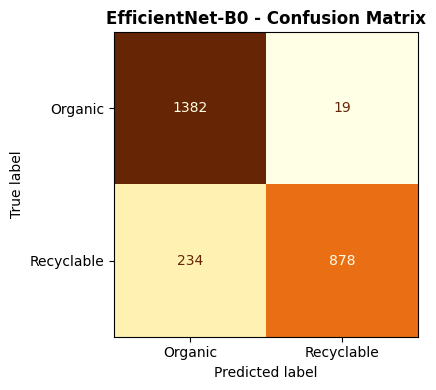

In [26]:
total_ep = len(en_hist['tl'])
ep2 = range(1, total_ep + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep2, en_hist['tl'], label='train', color='#2E86AB')
axes[0].plot(ep2, en_hist['vl'], label='val',   color='#A23B72', linestyle='--')
axes[0].axvline(EPOCHS_FINETUNE + 0.5, color='gray', linestyle=':', label='phase 2')
axes[0].set(xlabel='Epoch', ylabel='Loss',     title='EfficientNet-B0 Loss'); axes[0].legend()
axes[1].plot(ep2, en_hist['ta'], label='train', color='#2E86AB')
axes[1].plot(ep2, en_hist['va'], label='val',   color='#A23B72', linestyle='--')
axes[1].axvline(EPOCHS_FINETUNE + 0.5, color='gray', linestyle=':', label='phase 2')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='EfficientNet-B0 Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('efficientnet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_en, y_prob_en, y_true_en = predict(en_model, test_loader_en, DEVICE)
en_acc     = accuracy_score(y_true_en, y_pred_en)
en_f1      = f1_score(y_true_en, y_pred_en)
en_roc_auc = roc_auc_score(y_true_en, y_prob_en)

print('=== EfficientNet-B0 ===')
print(f'Accuracy:  {en_acc:.4f}')
print(f'F1-Score:  {en_f1:.4f}')
print(f'ROC-AUC:   {en_roc_auc:.4f}')
print()
print(classification_report(y_true_en, y_pred_en, target_names=['Organic', 'Recyclable']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true_en, y_pred_en),
                       display_labels=['Organic', 'Recyclable']).plot(ax=ax, colorbar=False, cmap='YlOrBr')
ax.set_title('EfficientNet-B0 - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_efficientnet.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
torch.save({
    'state_dict': en_model.state_dict(),
    'img_size':   (EN_SIZE, EN_SIZE),
    'class_map':  {'O': 0, 'R': 1},
}, 'saved/efficientnet_best.pt')
print('Saved: saved/efficientnet_best.pt')

Saved: saved/efficientnet_best.pt


### Model Comparison

Model                       Accuracy   F1-Score    ROC-AUC
----------------------------------------------------------
Logistic Regression           0.8233     0.7863     0.8784
Random Forest                 0.8699     0.8343     0.9473
SVM (PCA+LinearSVC)           0.8635     0.8319     0.9122
Custom CNN                    0.9085     0.8911     0.9685
EfficientNet-B0               0.8993     0.8741     0.9827


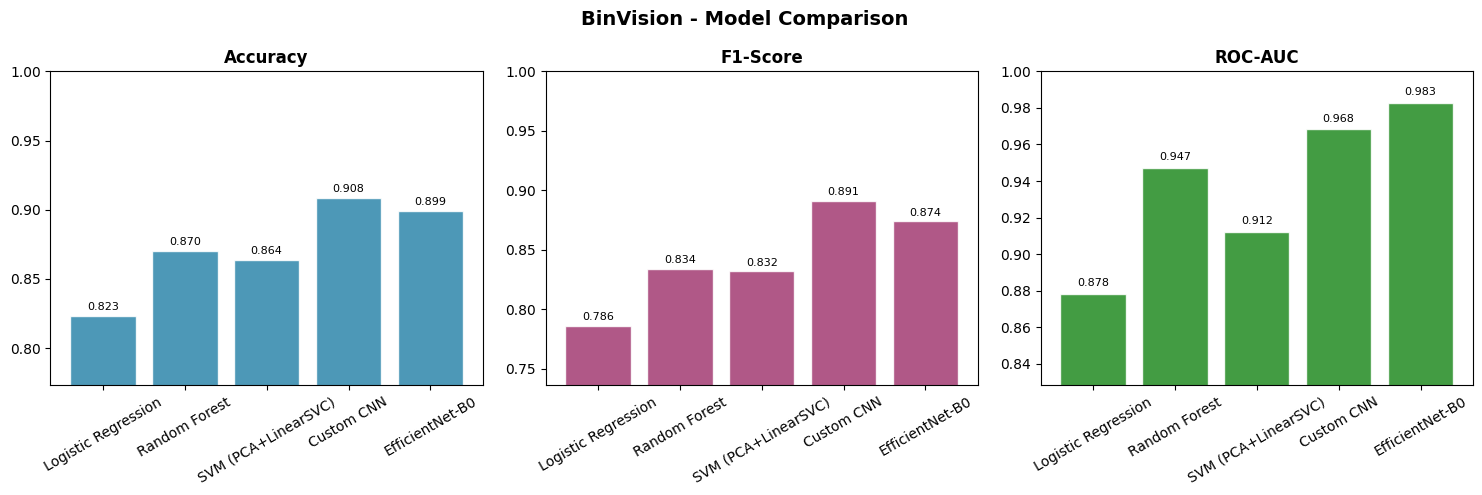

In [28]:
results = [
    ('Logistic Regression',  lr_acc,  lr_f1,  lr_roc_auc,  y_prob_lr,  y_test_flat),
    ('Random Forest',        rf_acc,  rf_f1,  rf_roc_auc,  y_prob_rf,  y_test_flat),
    ('SVM (PCA+LinearSVC)',  svm_acc, svm_f1, svm_roc_auc, y_prob_svm, y_test_flat),
    ('Custom CNN',           cnn_acc, cnn_f1, cnn_roc_auc, y_prob_cnn, y_true_cnn),
    ('EfficientNet-B0',      en_acc,  en_f1,  en_roc_auc,  y_prob_en,  y_true_en),
]

print(f'{"Model":<25} {"Accuracy":>10} {"F1-Score":>10} {"ROC-AUC":>10}')
print('-' * 58)
for name, acc, f1, auc, _, _ in results:
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names   = [r[0] for r in results]
metrics = [('Accuracy', [r[1] for r in results], '#2E86AB'),
           ('F1-Score', [r[2] for r in results], '#A23B72'),
           ('ROC-AUC',  [r[3] for r in results], '#228B22')]

for ax, (label, vals, color) in zip(axes, metrics):
    bars = ax.bar(names, vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_ylim(min(vals) - 0.05, 1.0)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('BinVision - Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

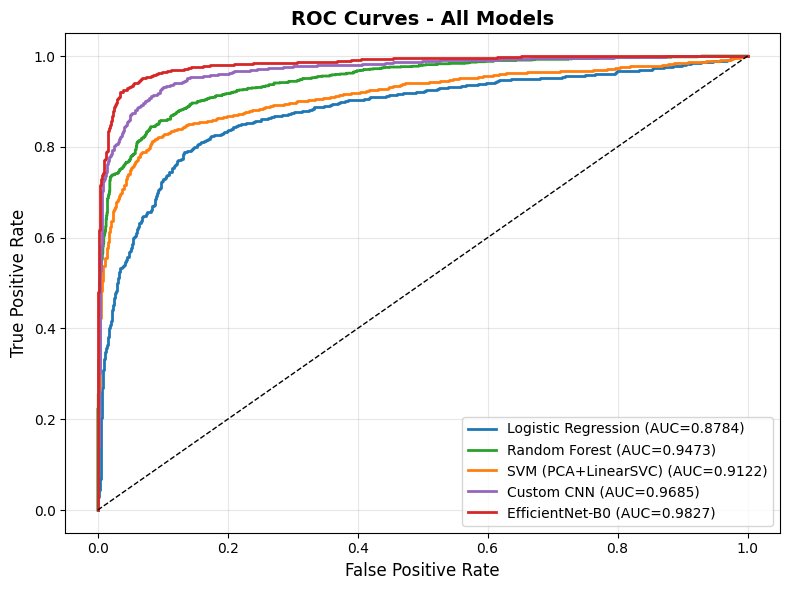

In [29]:
colors_roc = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728']
fig, ax    = plt.subplots(figsize=(8, 6))

for (name, _, _, _, probs, labels), color in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(labels, probs):.4f})',
            color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
import json as _json
config = {
    'classes':          ['O', 'R'],
    'label_map':        {'O': 0, 'R': 1},
    'cnn_img_size':     list(IMG_SIZE),
    'en_img_size':      [EN_SIZE, EN_SIZE],
    'imagenet_mean':    [0.485, 0.456, 0.406],
    'imagenet_std':     [0.229, 0.224, 0.225],
    'flat_img_size':    list(IMG_SIZE),
    'pca_components':   300,
}
with open('saved/preprocessing_config.json', 'w') as f:
    _json.dump(config, f, indent=2)
print('Saved: saved/preprocessing_config.json')
print()
print('All saved artifacts in saved/: ')
for fname in sorted(os.listdir('saved')):
    size_kb = os.path.getsize(f'saved/{fname}') / 1024
    print(f'  {fname}  ({size_kb:.0f} KB)')

Saved: saved/preprocessing_config.json

All saved artifacts in saved/: 
  cnn_best.pt  (2432 KB)
  efficientnet_best.pt  (15959 KB)
  flat_features.npz  (1277996 KB)
  lr_model.joblib  (385 KB)
  preprocessing_config.json  (0 KB)
  rf_model.joblib  (24435 KB)
  svm_pipe.joblib  (116759 KB)
